Дополнительное задание № 3 (5 баллов):
1. Загрузить последовательность отсчетов из файла «var\$\$_z3.bin», где \$\$ - номер варианта.
Формат записи данных в файле — бинарный, double (8 байт на отсчет); частота
дискретизации 1 кГц.
2. Рассчитать и построить на графике спектрограмму цифрового сигнала, использовав окно
(см. таблицу ниже) шириной 1000 отсчетов с перекрытием 999 отсчетов.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = np.fromfile("./data/lab_3_z3.bin", dtype=np.float64)
time = np.arange(len(data)) / 1000

len(data), len(time)

(10000, 10000)

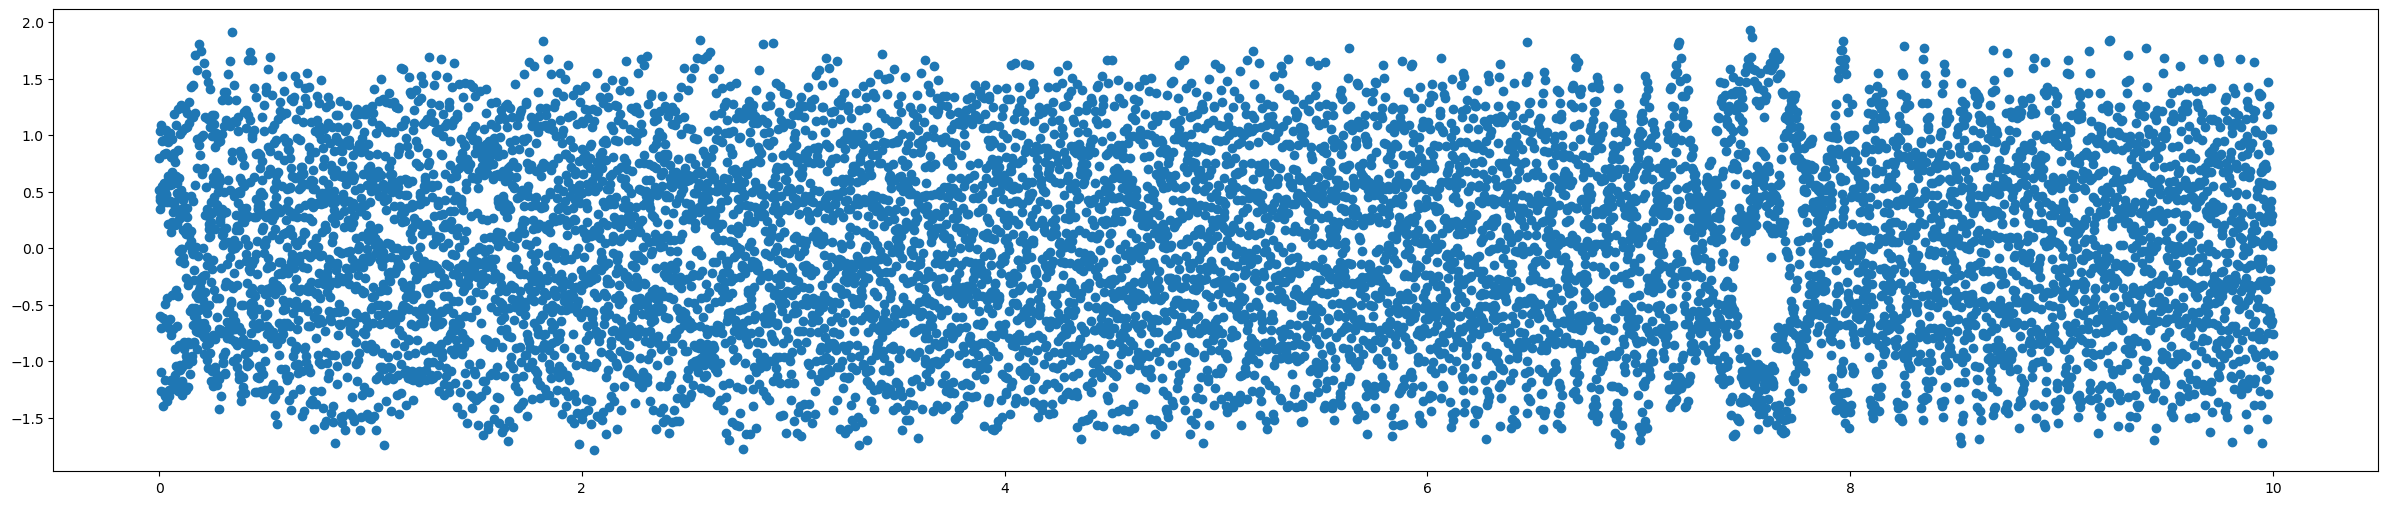

In [4]:
plt.figure(figsize=(30, 6))
plt.scatter(time, data)

In [5]:
def NattallWindow(n, N):
    a_0 = 0.3635819
    a_1 = 0.4891775
    a_2 = 0.1365995
    a_3 = 0.0106411
    
    cos_1 = np.cos(2 * np.pi * n / (N - 1))
    cos_2 = np.cos(4 * np.pi * n / (N - 1))
    cos_3 = np.cos(6 * np.pi * n / (N - 1))
    
    return a_0 - a_1 * cos_1 + a_2 * cos_2 - a_3 * cos_3

In [6]:
def FastFurieTransformAmpl(data):
    coef = 2 * np.pi / len(data)
    fft_data = []
    for k in range(len(data)):
        re_el = 0
        im_el = 0
        for n in range(len(data)):
            re_el += data[n] * np.cos(coef * k * n)
            im_el += -data[n] * np.sin(coef * k * n)
        fft_data.append((re_el, im_el))
    
    fft_data = [np.abs(fft_data[i][0]**2 + fft_data[i][1]**2) for i in range(len(fft_data[:len(data)//2]))]
    
    return fft_data

In [7]:
from scipy.signal import spectrogram
# Параметры STFT
window_size = 1000
overlap = 999
hop = window_size - overlap  # = 1

# Вычисление спектрограммы
frequencies, times, Sxx = spectrogram(
    data,
    fs=1000,
    window=np.blackman(window_size),
    nperseg=window_size,
    noverlap=overlap,
    mode='magnitude'  # или 'psd' для спектральной плотности мощности
)

# Перевод в логарифмический масштаб (дБ)
# Добавляем маленькое число, чтобы избежать log(0)
Sxx_db = 10 * np.log10(Sxx + 1e-12)

In [8]:
def stft_manual():
    fft_data = []
    for i in range(window_size // 2, len(data) - window_size // 2):
        start_ind = i 
        end_ind = start_ind + window_size
        
        window = data[start_ind:end_ind]
        window_data = [NattallWindow(k, len(window)) * window[k] for k in range(0, len(window))]
        
        fft_data.append(FastFurieTransformAmpl(window_data))
        print(i)
        #input(int())
    
    return fft_data
    

In [9]:
# Время для каждого сегмента (середина окна)
f = [1000 * i / window_size for i in range(window_size // 2)]

times = (np.arange(len(data) - window_size + 1) + window_size // 2) / 1000
times

array([0.5  , 0.501, 0.502, ..., 9.498, 9.499, 9.5  ], shape=(9001,))

In [10]:
def stft(signal, fs):
    window_size = 1000
    n_samples = len(signal)
    
    n_windows = (n_samples - window_size) // hop + 1
    
    # Частоты для БПФ (положительные частоты)
    freqs = np.fft.rfftfreq(window_size, 1/fs)
    
    Sxx = np.zeros((len(freqs), n_windows))
    
    for i in range(n_windows):
        start = i * hop
        end = start + window_size
        
        segment = signal[start:end] 
        segment = [NattallWindow(k, len(segment)) * segment[k] for k in range(0, len(segment))]
        
        # Вычисляем БПФ (только положительные частоты)
        fft_segment = np.fft.rfft(segment)
        
        Sxx[:, i] = np.abs(fft_segment)
    
    times = (np.arange(n_windows) + window_size/2) / fs
    
    return freqs, times, Sxx

freqs, times, Sxx = stft(data, fs=1000)
Sxx_db = 20 * np.log10(Sxx + 1e-12) 

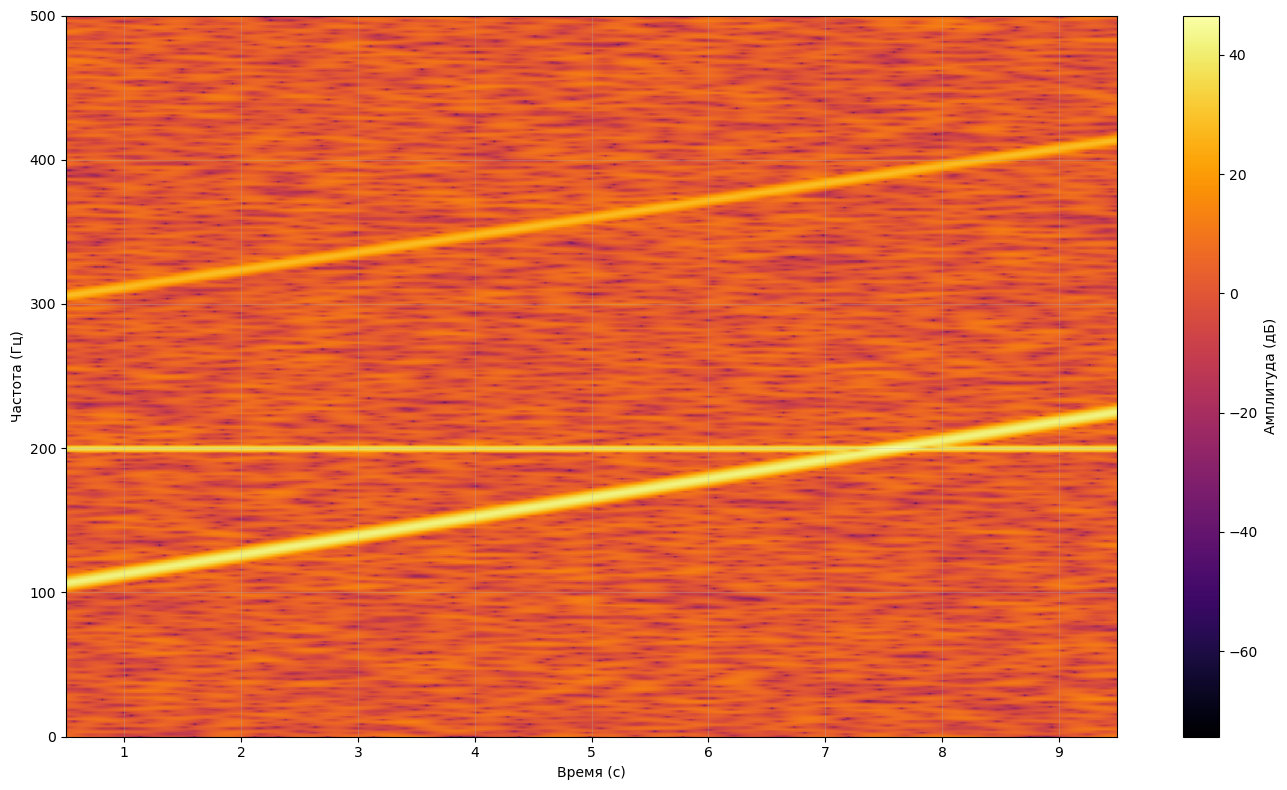

In [11]:

plt.figure(figsize=(14, 8))
plt.pcolormesh(times, frequencies, Sxx_db, 
               shading='gouraud', 
               cmap='inferno')

plt.colorbar(label='Амплитуда (дБ)')
plt.ylabel('Частота (Гц)')
plt.xlabel('Время (с)')

plt.ylim(0, 1000/2)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()